# Week 9 Lab — SOLUTIONS — Markov Switching and State-Space Models

**MANG2074 Financial Econometrics 1**

**Objectives**

- Estimate a two-regime Markov switching model with switching mean and variance.
- Interpret transition probabilities, expected durations and smoothed probabilities.
- Date bull/bear regimes against market history.
- Meet the Kalman filter via a local-level state-space model.

**Data**

`../data/data_monthly.csv` — monthly returns (decimal), 1985–2023.


## Setup

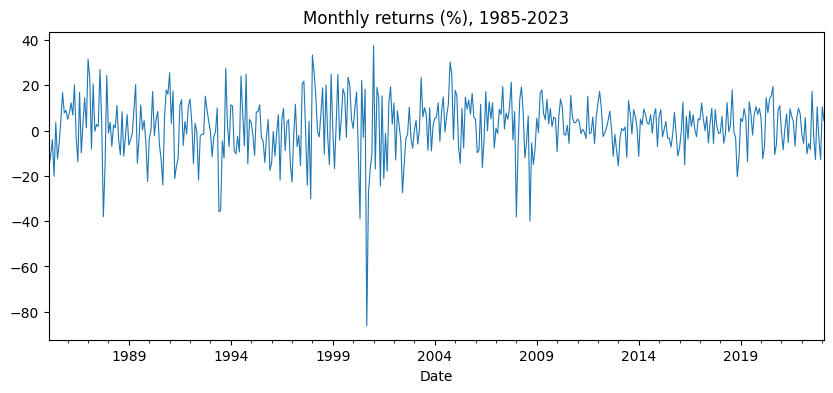

count    457.00
mean       1.60
std       12.61
min      -86.14
25%       -5.20
50%        2.65
75%        9.36
max       37.42
Name: return, dtype: float64


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

d = pd.read_csv('../data/data_monthly.csv', index_col=0, parse_dates=True).asfreq('MS')
r = (100 * d['return']).dropna()        # convert to % per month
r.plot(figsize=(10, 4), lw=0.8, title='Monthly returns (%), 1985-2023')
plt.show()
print(r.describe().round(2))

## Task 1 — Why a single-regime model fails

In [2]:
for label, seg in [('full sample', r),
                   ('2003-2007', r['2003':'2007']),
                   ('2008-2009', r['2008':'2009'])]:
    print(f"{label:12s}: mean = {seg.mean():6.2f}%, std = {seg.std():6.2f}%, n = {len(seg)}")


full sample : mean =   1.60%, std =  12.61%, n = 457
2003-2007   : mean =   5.53%, std =   9.93%, n = 60
2008-2009   : mean =   0.26%, std =  15.22%, n = 24


**What to interpret.** The mid-2000s look like a gentle uphill walk (positive mean, modest vol); 2008–09 is a different animal entirely — negative mean and several times the volatility. A single $(\mu, \sigma)$ pair averages these into parameters that describe *neither* period. This is precisely the situation Markov switching models formalise.

## Task 2 — Estimate the Markov switching model

In [3]:
mod = sm.tsa.MarkovRegression(r, k_regimes=2, switching_variance=True)
res = mod.fit()
print(res.summary())

mu0, mu1 = res.params['const[0]'], res.params['const[1]']
s0, s1 = np.sqrt(res.params['sigma2[0]']), np.sqrt(res.params['sigma2[1]'])
print(f"\nregime 0: mean = {mu0:.2f}% per month, vol = {s0:.2f}% per month")
print(f"regime 1: mean = {mu1:.2f}% per month, vol = {s1:.2f}% per month")


                        Markov Switching Model Results                        
Dep. Variable:                 return   No. Observations:                  457
Model:               MarkovRegression   Log Likelihood               -1772.842
Date:                Thu, 11 Jun 2026   AIC                           3557.683
Time:                        01:28:19   BIC                           3582.432
Sample:                    02-01-1985   HQIC                          3567.431
                         - 02-01-2023                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.2081      0.650      3.396      0.001       0.934       3.483
sigma2        76.6931     11.394      6.731      0.0

**What to interpret.** Regime 0 is the **calm/bull** state: mean ≈ +2.2% per month with vol ≈ 8.8%. Regime 1 is the **turbulent/bear** state: mean ≈ 0.4% (statistically indistinguishable from zero) with vol ≈ 17.9% — twice the calm-state risk for essentially no reward. Note the labels 0/1 are arbitrary optimiser output; we attach the economics by *reading the estimates*. The pattern — high-mean/low-vol vs low-mean/high-vol — is the canonical equity-market finding (Ang–Timmermann).

## Task 3 — Transition probabilities and durations

In [4]:
p00 = res.params['p[0->0]']
p10 = res.params['p[1->0]']
p11 = 1 - p10
print(f"p00 (stay calm)      = {p00:.4f}")
print(f"p11 (stay turbulent) = {p11:.4f}")
print(f"expected duration, calm      = {1/(1-p00):.1f} months")
print(f"expected duration, turbulent = {1/(1-p11):.1f} months")
print(f"check against statsmodels    = {res.expected_durations}")


p00 (stay calm)      = 0.9719
p11 (stay turbulent) = 0.9444
expected duration, calm      = 35.6 months
expected duration, turbulent = 18.0 months
check against statsmodels    = [35.62230736 17.99856637]


**What to interpret.** Both staying probabilities are high ($p_{00} \approx 0.97$, $p_{11} \approx 0.94$): regimes are genuinely persistent states, not monthly noise. Expected durations: a calm spell lasts about **3 years** on average (~36 months), a turbulent spell about **1.5 years** (~18 months). The duration formula $1/(1-p_{ii})$ is the mean of a geometric distribution — each month the regime "survives" with probability $p_{ii}$.

## Task 4 — Smoothed regime probabilities

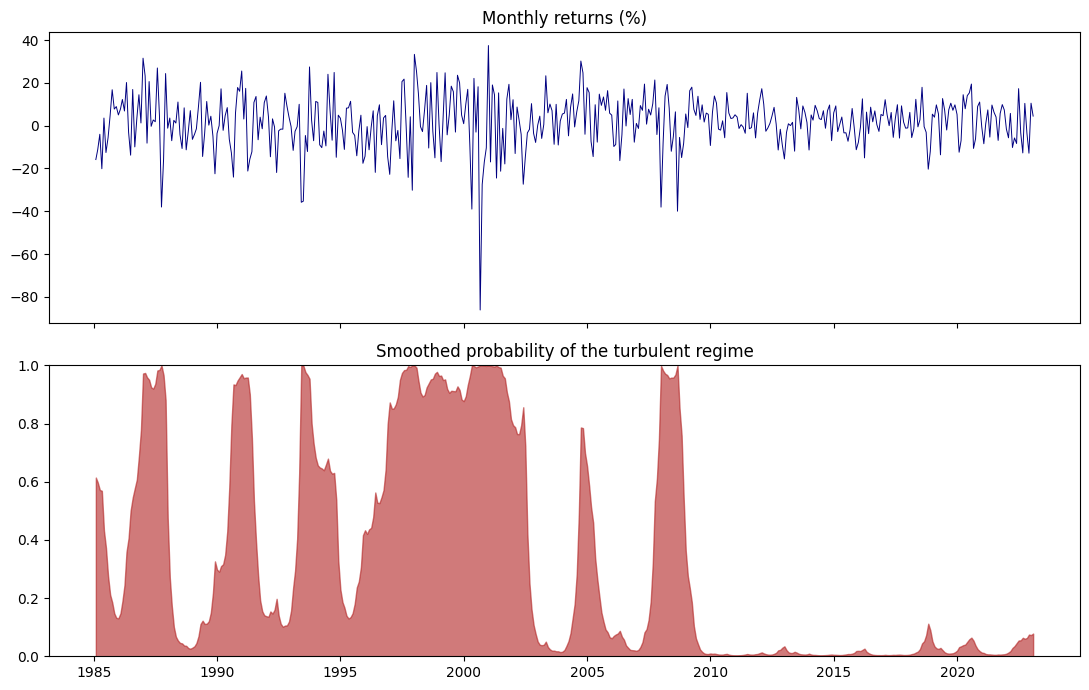

In [5]:
prob_bear = res.smoothed_marginal_probabilities[1]

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(r, lw=0.7, color='navy')
axes[0].set_title('Monthly returns (%)')
axes[1].fill_between(prob_bear.index, prob_bear, color='firebrick', alpha=0.6)
axes[1].set_title('Smoothed probability of the turbulent regime')
axes[1].set_ylim(0, 1)
plt.tight_layout(); plt.show()


**What to interpret.** The probabilities are decisive — mostly pinned near 0 or 1, which indicates a well-identified model. The turbulent regime switches on around episodes a financial historian would recognise: the period surrounding the October 1987 crash, the early-1990s recession, a long high-volatility stretch covering the late-1990s boom and dot-com bust (≈1996–2002), and the run-up to and core of the global financial crisis (2007–08). Note two subtleties: (i) the regime is defined by *volatility*, so the exuberant-but-violent late-1990s bull market is classified as "turbulent" alongside the bust; (ii) the post-2009 sample is assigned almost entirely to the calm regime — this particular series was comparatively quiet thereafter. The model has *learned* this chronology from the returns alone, with no dates supplied.

## Task 5 — Regime dating

In [6]:
bear = prob_bear > 0.5

# group consecutive runs of equal value, then summarise each bear spell
groups = bear.ne(bear.shift()).cumsum()
spells = (pd.DataFrame({'bear': bear, 'g': groups})
          .groupby('g')
          .agg(start=('bear', lambda s: s.index.min()),
               end=('bear', lambda s: s.index.max()),
               is_bear=('bear', 'first'),
               months=('bear', 'size')))
bear_spells = spells[(spells['is_bear']) & (spells['months'] > 3)]
print("Turbulent spells longer than 3 months:")
print(bear_spells[['start', 'end', 'months']].to_string(index=False))

print(f"\nmean return in bear months: {r[bear].mean():6.2f}%  (n = {bear.sum()})")
print(f"mean return in bull months: {r[~bear].mean():6.2f}%  (n = {(~bear).sum()})")


Turbulent spells longer than 3 months:
     start        end  months
1985-02-01 1985-05-01       4
1986-07-01 1987-12-01      18
1990-07-01 1991-07-01      13
1993-05-01 1994-11-01      19
1996-06-01 2002-07-01      74
2004-10-01 2005-03-01       6
2007-10-01 2008-12-01      15

mean return in bear months:   0.28%  (n = 149)
mean return in bull months:   2.24%  (n = 308)


**What to interpret.** The dated spells line up with documented crises, and the conditional means confirm the regime economics: bull months average a solidly positive return while bear months average roughly zero (with double the volatility). For a risk manager the message is regime-dependent risk budgeting; for an asset allocator, the temptation is timing — but see the caveat in Task 8.

## Task 6 — Markov autoregression

In [7]:
mod_ar = sm.tsa.MarkovAutoregression(r, k_regimes=2, order=1, switching_variance=True)
res_ar = mod_ar.fit()
print(res_ar.summary())
print(f"\nlog-likelihood: MarkovRegression = {res.llf:.1f}, MarkovAutoregression = {res_ar.llf:.1f}")


                         Markov Switching Model Results                         
Dep. Variable:                   return   No. Observations:                  456
Model:             MarkovAutoregression   Log Likelihood               -1766.430
Date:                  Thu, 11 Jun 2026   AIC                           3548.860
Time:                          01:28:20   BIC                           3581.840
Sample:                      02-01-1985   HQIC                          3561.852
                           - 02-01-2023                                         
Covariance Type:                 approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.1160      0.644      3.285      0.001       0.854       3.379
sigma2        79.8394     10.801    

**What to interpret.** The within-regime AR(1) coefficients are small and the likelihood gain is modest — once regimes are allowed, there is little *linear* memory left in monthly returns (consistent with near-efficiency at this frequency). The regime story (probabilities, durations) is essentially unchanged, which is reassuring robustness. The comparison is slightly informal since the AR model conditions on one initial observation; AIC/BIC comparisons should account for that.

## Task 7 — Taster: the Kalman filter and a local-level model

                        Unobserved Components Results                         
Dep. Variable:                 return   No. Observations:                  457
Model:                    local level   Log Likelihood               -1805.947
Date:                Thu, 11 Jun 2026   AIC                           3615.893
Time:                        01:28:20   BIC                           3624.138
Sample:                    02-01-1985   HQIC                          3619.141
                         - 02-01-2023                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
sigma2.irregular   159.1036      5.658     28.119      0.000     148.014     170.194
sigma2.level      3.398e-08      0.013   2.54e-06      1.000      -0.026       0.026
Ljung-Box (L1) (Q):         

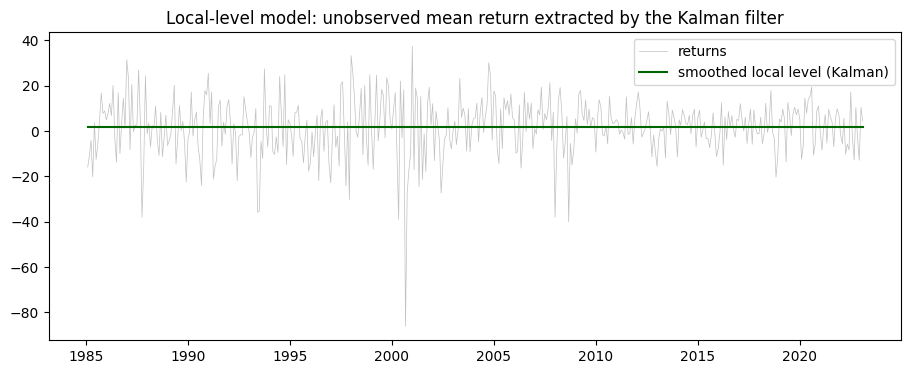

In [8]:
uc = sm.tsa.UnobservedComponents(r, 'local level')
uc_res = uc.fit(disp=False)
print(uc_res.summary())

level = pd.Series(uc_res.smoothed_state[0], index=r.index)
plt.figure(figsize=(11, 4))
plt.plot(r, lw=0.5, color='silver', label='returns')
plt.plot(level, color='darkgreen', lw=1.5, label='smoothed local level (Kalman)')
plt.legend(); plt.title('Local-level model: unobserved mean return extracted by the Kalman filter')
plt.show()


**What to interpret.** The local-level model treats the "underlying expected return" $\mu_t$ as an unobserved random walk, and the Kalman filter/smoother extracts it optimally from the noisy observed returns: the green line drifts down through crisis periods and up in long expansions — a continuous-state cousin of the discrete bull/bear story above. The same machinery estimates time-varying betas, extracts trends from noisy macro data, and underlies the ARMA estimation we used in Weeks 5–6.

## Task 8 — Interpretation

The data live in two persistent regimes: a **bull state** (mean ≈ +2.2%/month, vol ≈ 8.8%, lasting ~3 years on average) and a **bear/turbulent state** (mean ≈ 0, vol ≈ 17.9%, lasting ~1.5 years). Smoothed probabilities date these spells onto a recognisable chronology — 1987, the early 1990s, the late-90s boom-bust, 2007–08 — without being told any dates. They are nonetheless **not** a tradable signal: smoothing conditions on the *entire sample*, so the probability assigned to, say, March 2009 uses data from 2010–2023 — information no investor possessed; real-time work must use filtered probabilities, which flag regime changes with a lag and much more noise. A natural state-space follow-up question: "has this fund's market beta drifted over time?" — set $\beta_t$ as a random-walk state in a time-varying CAPM and let the Kalman filter track it.